In [ ]:
# project description:
# 

In [185]:
!pip install plotly pandas requests geopy

In [226]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

us_dc = dc[dc['Country'] == 'United States'].copy()
us_dc = us_dc[us_dc['Address'].notna()].copy()

us_dc['Owner_clean'] = us_dc['Owner'].str.replace(r'\s*#\w+', '', regex=True).str.strip()
us_dc['Owner_clean'] = us_dc['Owner_clean'].fillna('Unknown')

geolocator = Nominatim(user_agent="datacenter_map")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coords(address):
    try:
        loc = geocode(address, timeout=10)
        if loc:
            return loc.latitude, loc.longitude
    except:
        pass
    return None, None

us_dc[['lat', 'lon']] = us_dc['Address'].apply(
    lambda a: pd.Series(get_coords(a))
)

print(us_dc[['Name', 'Owner_clean', 'lat', 'lon']].to_string())

                             Name Owner_clean        lat         lon
0                      Colossus 2    SpaceXAI  34.997983  -90.034867
1     Microsoft Fairwater Atlanta   Microsoft  33.445492  -84.524115
2   Anthropic-Amazon New Carlisle      Amazon        NaN         NaN
3   Microsoft Fairwater Wisconsin   Microsoft  42.674872  -87.894882
4                 Meta Prometheus        Meta        NaN         NaN
5                    QTS Richmond     Unknown  37.488827  -77.247490
6                      Colossus 1    SpaceXAI  35.073554  -90.087308
7         OpenAI Stargate Abilene      Oracle  32.494232  -99.800907
8                 Google Columbus      Google  39.861452  -83.004000
9        Amazon Madison Mega Site      Amazon        NaN         NaN
10              Google New Albany      Google  40.070051  -82.754042
11             Microsoft Goodyear   Microsoft  33.408991 -112.364800
12                    Meta Temple        Meta  31.125960  -97.359818
13                   Google Omaha 

In [220]:
# Fix casing
us_dc['Owner'] = us_dc['Owner_clean'].replace('Coreweave', 'CoreWeave')
us_dc['Owner'] = us_dc['Owner'].str.replace(r'\s*#\w+', '', regex=True).str.strip()
us_dc['Owner'] = us_dc['Owner'].fillna('Unknown')

# Manual coords for failed geocoding
manual_coords = {
    'Anthropic-Amazon New Carlisle': (41.7009, -86.5220),
    'Meta Prometheus': (40.0742, -82.7913),
    'Amazon Madison Mega Site': (32.6121, -90.0357),
    'Microsoft Project Osmium': (41.5051, -93.9856),
    'Goodnight': (34.9770, -101.3569),
    'Coreweave Helios': (33.0373, -100.9218),
    'OpenAI Stargate Shackelford': (32.4940, -99.8007),
    'OpenAI Stargate Lordstown': (41.2387, -80.8151),
    'OpenAI Stargate New Mexico': (35.0853, -106.6500),
    'OpenAI Stargate Wisconsin': (43.0731, -89.4012),
    'OpenAI Stargate Michigan': (42.3314, -83.0458),
    'OpenAI Stargate Milam': (30.7552, -96.9997),
    'Google Kansas City East': (39.0997, -94.5786),
    'Vantage TX1': (33.4484, -112.3740),
}

for name, (lat, lon) in manual_coords.items():
    mask = us_dc['Name'] == name
    us_dc.loc[mask, 'lat'] = lat
    us_dc.loc[mask, 'lon'] = lon

print(f"Missing coords remaining: {us_dc['lat'].isna().sum()}")

# Prep timeline
tl['Date'] = pd.to_datetime(tl['Date'])
tl['Year'] = tl['Date'].dt.year
tl_op = tl[tl['Power (MW)'] > 0].copy()
tl_yearly = (
    tl_op.groupby(['Data center', 'Year'])['Power (MW)']
    .max()
    .reset_index()
)

Missing coords remaining: 0


(43, 15) ['Name', 'Current H100 equivalents', 'Current power (MW)', 'Current total capital cost (2025 USD billions)', 'Owner', 'Users', 'Notes', 'Selected Sources', 'Calculations sheet', 'Project', 'Investors', 'Construction companies', 'Energy companies', 'Country', 'Address']
(247, 14) ['Date', 'Construction status', 'Buildings operational', 'IT power (MW)', 'Power (MW)', 'H100 equivalents', 'Total capital cost (2025 USD billions)', 'Performance (8-bit OP/s)', 'Compute cost (2025 USD billions)', 'Construction cost (2025 USD billions)', 'Water use (MGD)', 'Data center', 'Current H100 equivalents (from Data center)', 'Thumbnail']
Missing coords remaining: 0


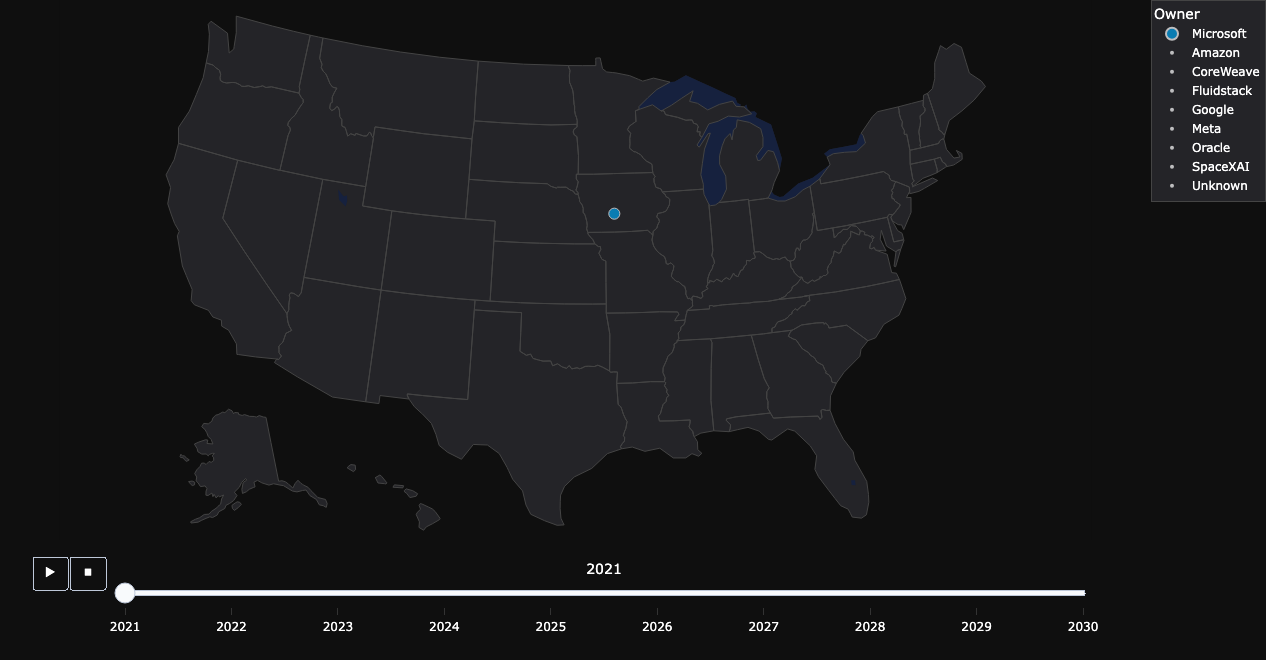

In [377]:
import pandas as pd
import requests
from io import StringIO
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import plotly.express as px

dc_url = "https://epoch.ai/data/data_centers/data_centers.csv"
tl_url = "https://epoch.ai/data/data_centers/data_center_timelines.csv"
dc_raw = requests.get(dc_url).text
tl_raw = requests.get(tl_url).text
dc = pd.read_csv(StringIO(dc_raw))
tl = pd.read_csv(StringIO(tl_raw))
print(dc.shape, dc.columns.tolist())
print(tl.shape, tl.columns.tolist())

# Fix casing
us_dc['Owner'] = us_dc['Owner_clean'].replace('Coreweave', 'CoreWeave')
us_dc['Owner'] = us_dc['Owner'].str.replace(r'\s*#\w+', '', regex=True).str.strip()
us_dc['Owner'] = us_dc['Owner'].fillna('Unknown')

# Manual coords for failed geocoding
manual_coords = {
    'Anthropic-Amazon New Carlisle': (41.7009, -86.5220),
    'Meta Prometheus':               (40.0742, -82.7913),
    'Amazon Madison Mega Site':      (32.6121, -90.0357),
    'Microsoft Project Osmium':      (41.5051, -93.9856),
    'Goodnight':                     (34.9770, -101.3569),
    'Coreweave Helios':              (33.0373, -100.9218),
    'OpenAI Stargate Shackelford':   (32.4940, -99.8007),
    'OpenAI Stargate Lordstown':     (41.2387, -80.8151),
    'OpenAI Stargate New Mexico':    (35.0853, -106.6500),
    'OpenAI Stargate Wisconsin':     (43.0731, -89.4012),
    'OpenAI Stargate Michigan':      (42.3314, -83.0458),
    'OpenAI Stargate Milam':         (30.7552, -96.9997),
    'Google Kansas City East':       (39.0997, -94.5786),
    'Vantage TX1':                   (33.4484, -112.3740),
}
for name, (lat, lon) in manual_coords.items():
    mask = us_dc['Name'] == name
    us_dc.loc[mask, 'lat'] = lat
    us_dc.loc[mask, 'lon'] = lon
print(f"Missing coords remaining: {us_dc['lat'].isna().sum()}")

# Prep timeline
tl['Date'] = pd.to_datetime(tl['Date'])
tl['Year'] = tl['Date'].dt.year
tl_op = tl[tl['Power (MW)'] > 0].copy()
tl_yearly = (
    tl_op.groupby(['Data center', 'Year'])['Power (MW)']
    .max()
    .reset_index()
)

merged = tl_yearly.merge(
    us_dc[['Name', 'Owner', 'lat', 'lon']],
    left_on='Data center',
    right_on='Name',
    how='inner'
)
all_years = sorted(range(merged['Year'].min(), merged['Year'].max() + 1))
rows = []
for name in merged['Name'].unique():
    site = merged[merged['Name'] == name].set_index('Year')
    owner = us_dc.loc[us_dc['Name'] == name, 'Owner'].iloc[0]
    lat = site['lat'].iloc[0]
    lon = site['lon'].iloc[0]
    for year in all_years:
        past = site[site.index <= year]
        if not past.empty:
            power = past['Power (MW)'].max()
            rows.append({
                'Name': name,
                'Owner': owner,
                'lat': lat,
                'lon': lon,
                'Power (MW)': power,
                'Year': str(year),
            })
anim_df = pd.DataFrame(rows)

# ── Reverse geocode city/state for each unique site ──
geolocator = Nominatim(user_agent="datacenter_map")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_location(lat, lon):
    try:
        loc = reverse(f"{lat}, {lon}", language='en')
        addr = loc.raw['address']
        city = addr.get('city') or addr.get('town') or addr.get('village') or addr.get('county', '')
        state = addr.get('state', '')
        return city, state
    except:
        return '', ''

unique_sites = anim_df[['Name', 'lat', 'lon']].drop_duplicates(subset='Name')
unique_sites[['City', 'State']] = unique_sites.apply(
    lambda r: pd.Series(get_location(r['lat'], r['lon'])), axis=1
)
anim_df = anim_df.merge(unique_sites[['Name', 'City', 'State']], on='Name', how='left')

# ── Dummy rows to keep legend stable across frames ──
all_owners = anim_df['Owner'].unique()
dummy_rows = []
for year in [str(y) for y in all_years]:
    for owner in all_owners:
        dummy_rows.append({
            'Name': f'__dummy_{owner}',
            'Owner': owner,
            'lat': 38.5, 'lon': -98.0,
            'Power (MW)': 0,
            'Year': year,
            'City': '',
            'State': '',
        })
anim_df = pd.concat([anim_df, pd.DataFrame(dummy_rows)], ignore_index=True)
anim_df = anim_df.sort_values(['Year', 'Name'])

owner_colors = {
    'Microsoft':  '#00a2ed',
    'Meta': '#1877f2',
    'Google': '#34a853',
    'Amazon': '#ff9900',
    'Oracle': '#f80000',
    'SpaceXAI': '#cc0000',
    'CoreWeave': '#7b2d8b',
    'Fluidstack': '#00b4d8',
    'Unknown': '#aaaaaa',
    'Softbank': '#cc6600',
}

fig = px.scatter_geo(
    anim_df,
    lat='lat', lon='lon',
    size='Power (MW)',
    color='Owner',
    hover_name='Name',
    hover_data={
        'Power (MW)': True,
        'Owner': True,
        'City': True,
        'State': True,
        'lat': False,
        'lon': False,
    },
    animation_frame='Year',
    scope='usa',
    size_max=60,
    color_discrete_map=owner_colors,
)

fig.update_layout(
    geo=dict(
        bgcolor='#0f0f0f',
        landcolor='#242428',
        lakecolor='#16213e',
        subunitcolor='#444',
        showland=True,
        showlakes=True,
        showsubunits=True,
    ),
    paper_bgcolor='#0f0f0f',
    plot_bgcolor='#0f0f0f',
    font=dict(color='white'),
    legend=dict(
            bgcolor='#242428',
            bordercolor='#444',
            borderwidth=1,
            x=1, # push left, was defaulting to ~1.02 outside the plot
            y=1,
            xanchor='left',
            yanchor='top',
        ),
    title=dict(
        x=0.5,
        font=dict(size=18),
    ),
    height=660,
    margin=dict(l=0, r=0, t=0, b=120),
)

fig.update_traces(
    hovertemplate=(
        '<b>%{hovertext}</b><br>'
        '%{customdata[2]}, %{customdata[3]}<br>'
        'Owner = %{customdata[0]}<br>'
        'Power (MW) = %{customdata[1]}'
        '<extra></extra>'
    )
)

fig.layout.sliders[0].currentvalue.visible = True
fig.layout.sliders[0].currentvalue.prefix = ''
fig.layout.sliders[0].currentvalue.font = dict(size=14, color='white')
fig.layout.sliders[0].currentvalue.xanchor = 'center'

fig.layout.sliders[0].update(
    y=-0.02,
    len=0.85,
    x = 0.1,
    pad=dict(t=5, b=5),
)

fig.layout.updatemenus[0].update(
    y=-0.02,
    pad=dict(t=5, b=5),
)

for button in fig.layout.updatemenus[0].buttons:
    button.args[1]['frame']['duration'] = 800

fig.show()

In [369]:
import base64

with open('/Users/oliviadh/qiong_python_projs/amazon_data_center_ai_0822202_AP25205716134331-1.webp', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode('utf-8')
img_src = f"data:image/webp;base64,{img_data}"

html = fig.to_html(full_html=False, include_plotlyjs='cdn')

full_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Tracking US AI Data Centers</title>
    <style>
        *, *::before, *::after {{ margin: 0; padding: 0; box-sizing: border-box; }}

        :root {{
            --bg: #0C0C0C;
            --white: #EAEAEA;
            --dim: #A4A4A4;
            --border: #1e1e1e;
            --font: 'Helvetica Neue', 'HelveticaNeue', Helvetica, Arial, sans-serif;
            --mono: 'Roboto Mono', Roboto, monospace;
            --quote: 'Nanum Myeongjo', serif;
        }}

        html, body {{
            height: 100%;
            background: var(--bg);
            color: var(--white);
            font-family: var(--font);
            overflow: hidden;
            margin-bottom: 3em;
        }}

        ol {{
            font-size: 0.65rem;
            color: var(--dim);
            line-height: 1.95;
            font-family: var(--mono) !important;
            font-weight: 200 !important;
            letter-spacing: 0.05em;
        }}

        a {{
            color: var(--dim);
        }}

        a:hover {{
            color: var(--white);
            font-weight: 500;
        }}

        a:visited {{
            color: var(--white);
            font-weight: 500;
        }}

        figcaption {{
            font-size: 0.65rem;
            color: var(--dim);
            line-height: 1.95;
            font-family: var(--mono) !important;
            font-weight: 200 !important;
            letter-spacing: 0.05em;
        }}

        blockquote {{
            font-family: var(--quote);
        }}

        nav {{
            position: fixed;
            top: 0; left: 0; right: 0;
            z-index: 100;
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 16px 28px;
            background: rgba(10, 10, 10, 0.6);
            backdrop-filter: blur(16px);
            -webkit-backdrop-filter: blur(16px);
        }}

        .nav-logo {{
            font-size: 0.7rem;
            letter-spacing: 0.18em;
            text-transform: uppercase;
            color: var(--dim);
            font-family: var(--mono);
        }}

        .nav-toggle {{
            display: flex;
            background: #111;
            border: 1px solid #2a2a2a;
            border-radius: 100px;
            padding: 5px;
            gap: 2px;
            position: relative;
        }}

        .toggle-btn {{
            position: relative;
            z-index: 1;
            padding: 9px 22px;
            border-radius: 100px;
            font-size: 0.72rem;
            letter-spacing: 0.12em;
            text-transform: uppercase;
            font-weight: 600;
            font-family: var(--font);
            color: var(--white);
            background: transparent;
            border: none;
            cursor: pointer;
            transition: color 0.3s ease;
            display: flex;
            align-items: center;
            gap: 7px;
        }}

        .toggle-btn.active {{ color: #0a0a0a; }}

        .toggle-pill {{
            position: absolute;
            top: 5px;
            height: calc(100% - 10px);
            background: var(--white);
            border-radius: 100px;
            transition: left 0.35s cubic-bezier(0.4, 0, 0.2, 1), width 0.35s cubic-bezier(0.4, 0, 0.2, 1);
            z-index: 0;
        }}

        .nav-right {{
            font-family: var(--mono);
            font-size: 0.7rem;
            color: var(--dim);
            letter-spacing: 0.12em;
            text-transform: uppercase;
        }}

        .page {{
            position: fixed;
            inset: 0;
            opacity: 0;
            pointer-events: none;
            transition: opacity 0.4s ease;
            overflow-y: auto;
        }}

        .page.active {{
            opacity: 1;
            pointer-events: all;
        }}

        #map-page {{ background: var(--bg); }}

        #map-page .plotly-graph-div {{
            width: 100% !important;
            height: calc(100vh - 200px) !important;
        }}

        .map-header {{
            padding: 75px 64px 20px;
            display: flex;
            flex-direction: column;
            justify-content: center;
            align-items: center;
            border-bottom: 1px solid var(--border);
        }}

        .map-header h2 {{
            font-size: 3em;
            font-weight: 500;
            text-align: center;
            letter-spacing: 0.02em;
            line-height: 0.95;
            color: var(--white);
            padding-bottom: 8px;
        }}

        .map-meta {{
            font-family: var(--font);
            font-size: 1rem;
            color: var(--dim);
            letter-spacing: 0.01em;
            font-weight: 400;
            text-align: center;
            line-height: 2;
        }}

        #info-page {{ background: var(--bg); }}

        .info-hero {{
            padding: 120px 64px 56px;
            border-bottom: 1px solid var(--border);
        }}

        .info-hero h2 {{
            font-size: 3em;
            font-weight: 500;
            letter-spacing: 0.02em;
            line-height: 0.95;
            color: var(--white);
            text-align: center;
        }}

        .info-page-inner {{
            display: flex;
            flex-direction: column;
        }}

        .info-body {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            border-bottom: 1px solid var(--border);
        }}

        .info-col {{
            padding: 56px 64px;
        }}

        .info-col + .info-col {{ border-left: 1px solid var(--border); }}

        .col-label {{
            font-family: var(--mono);
            font-weight: 300;
            font-size: 0.65rem;
            letter-spacing: 0.18em;
            text-transform: uppercase;
            color: var(--dim) !important;
            margin-bottom: 40px;
        }}

        .stat {{ margin-bottom: 44px; }}

        .stat .fig {{
            font-size: 3.8rem;
            font-weight: 400;
            line-height: 1;
            margin-bottom: 10px;
            color: var(--white);
        }}

        .stat .note {{
            font-size: 0.88rem;
            color: var(--white);
            line-height: 1.95;
            max-width: 360px;
            font-weight: 300;
            letter-spacing: 0.05em;
        }}

        .info-col p {{
            font-size: 0.92rem;
            color: var(--white);
            line-height: 1.95;
            margin-bottom: 22px;
            font-weight: 300;
            letter-spacing: 0.05em;
        }}

        .info-col p strong {{
            color: var(--white);
            font-weight: 300;
        }}

        .pull {{
            padding: 56px 64px;
            border-bottom: 1px solid var(--border);
        }}

        .pull blockquote {{
            font-size: clamp(1.3rem, 2.2vw, 2rem);
            font-weight: 400;
            line-height: 1.5;
            letter-spacing: 0.01em;
            max-width: 780px;
            color: var(--white);
        }}

        .pull cite {{
            display: block;
            margin-top: 20px;
            font-size: 0.68rem;
            font-family: var(--mono);
            color: var(--dim);
            letter-spacing: 0.1em;
            font-style: normal;
        }}

        footer {{
            padding: 28px 64px;
            display: flex;
            justify-content: space-between;
            border-top: 1px solid var(--border);
        }}

        footer span {{
            font-family: var(--mono);
            font-size: 0.65rem;
            color: var(--dim);
            letter-spacing: 0.08em;
        }}

        .dc-image {{
    width: 100%;
    height: 400px;
    object-fit: cover;
}}

@media (max-width: 480px) {{
    .dc-image {{
        height: 220px;
    }}
}}

@media (max-width: 768px) and (min-width: 481px) {{
    .dc-image {{
        height: 280px;
    }}
}}

        /* ── Tablet (≤ 768px) ── */
        @media (max-width: 768px) {{
            nav {{
                padding: 20px 24px;
            }}

            .info-hero {{
                padding: 90px 32px 36px;
            }}

            .info-hero h2 {{
                font-size: 2em;
                text-align: center;
            }}

            .info-page-inner {{
                display: flex;
                flex-direction: column;
            }}

            .info-body {{
                grid-template-columns: 1fr;
                display: flex;
                flex-direction: column;
                border-bottom: none;
            }}

            .info-col:last-child {{
                order: 1;
                border-left: none;
                border-top: 1px solid var(--border);
                border-bottom: 1px solid var(--border);
                padding: 36px 32px;
            }}

            .info-col:first-child {{
                order: 2;
                border-top: none;
                border-bottom: 1px solid var(--border);
                padding: 36px 32px;
            }}

            .pull {{
                order: 3;
                padding: 36px 32px;
            }}

            .pull blockquote {{
                font-size: 1.2rem;
            }}

            footer {{
                padding: 20px 32px;
                flex-direction: column;
                gap: 6px;
            }}

            ol {{
                padding-left: 1.4em;
            }}

            #map-page .plotly-graph-div {{
                height: 75vh !important;
            }}
        }}

        /* ── Phone (≤ 480px) ── */
        @media (max-width: 480px) {{
            nav {{
                padding: 16px 20px;
            }}

            .nav-logo {{
                font-size: 0.6rem;
            }}

            .nav-right {{
                font-size: 0.6rem;
            }}

            .toggle-btn {{
                padding: 8px 14px;
                font-size: 0.65rem;
            }}

            .map-header {{
                padding: 72px 20px 16px;
            }}

            .map-header h2 {{
                font-size: 1.4em;
            }}

            .map-meta {{
                font-size: 0.7rem;
            }}

            #map-page .plotly-graph-div {{
                height: 75vh !important;
            }}

            .info-hero {{
                padding: 80px 20px 28px;
            }}

            .info-hero h2 {{
                font-size: 1.6em;
            }}

            .info-col:last-child,
            .info-col:first-child {{
                padding: 28px 20px;
            }}

            .info-col p {{
                font-size: 0.85rem;
            }}

            .pull {{
                padding: 28px 20px;
            }}

            .pull blockquote {{
                font-size: 1rem;
            }}

            footer {{
                padding: 16px 20px;
            }}

            iframe {{
                height: 220px;
            }}

            ol {{
                padding-left: 1.4em;
            }}
        }}
    </style>
</head>
<body>

<nav>
    <span class="nav-logo">Qiong 2026</span>
    <div class="nav-toggle" id="navToggle">
        <div class="toggle-pill" id="togglePill"></div>
        <button class="toggle-btn active" id="btn-map" onclick="showPage('map-page', 0)">
            <svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round">
                <path d="M20 10c0 6-8 12-8 12s-8-6-8-12a8 8 0 0 1 16 0Z"/>
                <circle cx="12" cy="10" r="3"/>
            </svg>
        </button>
        <button class="toggle-btn" id="btn-about" onclick="showPage('info-page', 1)">
            <svg xmlns="http://www.w3.org/2000/svg" width="13" height="13" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round">
                <line x1="3" y1="6" x2="21" y2="6"/>
                <line x1="3" y1="12" x2="21" y2="12"/>
                <line x1="3" y1="18" x2="21" y2="18"/>
            </svg>
        </button>
    </div>
    <span class="nav-right">
<a href="https://linktr.ee/stopthedata">Fight Back</a></span>
</nav>

<!-- MAP PAGE -->
<div class="page active" id="map-page">
    <div class="map-header">
        <h2>Tracking AI Data Centers in the US</h2>
        <div class="map-meta">
            Source: Epoch AI Frontier Database  |  Bubble size = power capacity (MW)
        </div>
    </div>
    {html}
    <footer>
        <span>Data: epoch.ai/data/data-centers</span>
        <span>Built with Python + Plotly</span>
    </footer>
</div>

<!-- INFO PAGE -->
<div class="page" id="info-page">
    <div class="info-hero">
        <h2>AI Data Centers</h2>
    </div>
    <div class="info-page-inner">
        <div class="info-body">
            <div class="info-col">
                <p class="col-label">Media Gallery</p>
                <div class="stat">
                    <figure>
                        <img src="amazon_data_center_ai_0822202_AP25205716134331-1.webp" alt="AI data center" class="dc-image">
                        <figcaption>Amazon Web Services data centre is seen in 2024 in Boardman, Ore. <br> Jenny Kane/The Associated Press</figcaption>
                    </figure>
                </div>
                <div style="margin-top: 8px;">
                    <iframe width="100%" height="400" src="https://www.youtube.com/embed/DGjj7wDYaiI?si=ANGRzlVHaIk2V8WS" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen style="border: 1px solid var(--border); border-radius: 4px;"></iframe>
                </div>
            </div>

            <div class="info-col">
                <p class="col-label">The Bigger Picture</p>
                <p>Since 2021, AI data centers have been popping up across rural America. These facilities power AI applications and services like ChatGPT and Palantir. But behind the promise that new jobs will be added and that wealth will just "trickle down", deviously lies the exploitation of land, natural resources, and energy that will line the pockets of a select few, funded by the lower and middle working class.</p>
                <p>The recent emergence of these centers is a direct consequence of late-stage capitalism and technofacism, where only a select few tech oligarchs gain capital and influence over the political system that provides the very permission structure that enables this. Scholars like Yanis Varoufakis have argued that we are entering a technofeudal era, where controlling the <i>infrastructure</i> that powers AI yields more economic power and capital than competing in any free market [1]. This is the motivation driving the arms race between tech oligarchs to build ever more powerful data centers. Essentially, these Big Tech companies, from the top down, charge ordinary working class to exist in the emerging world of artificial intelligence that these very companies build and control.</p>
                <p>Rural communities bear the brunt of these impacts. It is no accident that Big Tech targets areas where land is cheap and property taxes are low. Iowa, home to the first recorded Microsoft AI data center, is emblematic of a broader pattern. Local governments are promised jobs and tax revenue; what arrives instead are largely automated facilities employing contract workers in the single digits. Permanent employment is never realized. As scholars of fascism, like Ruth Ben-Ghiat have noted, authoritarian economic structures tend to begin by targeting the most vulnerable and least politically powerful and then expand outward, a technique that comes directly out of the authoritarian playbook [2].</p>
                <p>The public health consequences are both immediate and long-term. Data centers running on fossil fuels and diesel generators emit nitrogen oxides and fine particulate matter, pollutants with well-documented links to respiratory illness, cardiovascular disease, and, otherwise preventable death [3]. These effects do not fall evenly across the population. Lower-income rural communities, which often already face reduced access to healthcare and higher baseline rates of chronic disease, absorb disproportionate pollution burdens while seeing little of the promised economic benefit. The cumulative burden, degraded air quality layered on top of economic stagnation, strained local infrastructure, and increased water consumption by cooling systems, constitutes a public health crisis that is largely invisible in national conversations about the real costs of AI.</p>
                <br>
                <ol>
                    <li>Varoufakis, Y. (2023). Technofeudalism: What killed capitalism. The Bodley Head.</li>
                    <li>Ben-Ghiat, R. (2020). Strongmen: Mussolini to the present. W. W. Norton.</li>
                    <li>Tao, Y., & Gao, P. (2025). Global data center expansion and human health: A call for empirical research. Eco-Environment & Health, 4(3), 100157. https://doi.org/10.1016/j.eehl.2025.100157</li>
                </ol>
                <br>
            </div>
        </div>
        <div class="pull">
            <blockquote>
                <i>"We are witnessing the enclosure of digital commons — the transformation of shared computational potential into private infrastructure controlled by a shrinking number of actors."</i>
                <cite>— Adapted from Yanis Varoufakis, Technofeudalism (2023)</cite>
            </blockquote>
        </div>
    </div>
    <footer>
        <span>© 2026 Olivia Qiong</span>
        <span>Built with Python · Plotly · Epoch AI data</span>
    </footer>
</div>

<script>
    const btns = [document.getElementById('btn-map'), document.getElementById('btn-about')];
    const pill = document.getElementById('togglePill');

    function movePill(idx) {{
        const btn = btns[idx];
        pill.style.left = btn.offsetLeft + 'px';
        pill.style.width = btn.offsetWidth + 'px';
    }}

    function showPage(pageId, btnIdx) {{
        document.querySelectorAll('.page').forEach(p => p.classList.remove('active'));
        document.getElementById(pageId).classList.add('active');
        btns.forEach(b => b.classList.remove('active'));
        btns[btnIdx].classList.add('active');
        movePill(btnIdx);
    }}

    function fixMapForMobile() {{
        const plotDiv = document.querySelector('#map-page .plotly-graph-div');
        if (!plotDiv || window.innerWidth > 768) return;
        Plotly.relayout(plotDiv, {{
            'legend.x': 0.01,
            'legend.y': 0.99,
            'legend.xanchor': 'left',
            'legend.yanchor': 'top',
            'legend.font.size': 8,
            'legend.bgcolor': 'rgba(26,26,46,0.75)',
            'margin.l': 0,
            'margin.r': 0,
            'margin.t': 0,
            'margin.b': 60,
            'height': Math.round(window.innerHeight * 0.75),
        }});
    }}

    window.addEventListener('load', () => {{
        movePill(0);
        setTimeout(fixMapForMobile, 800);
    }});

    window.addEventListener('resize', () => {{
        const active = btns.findIndex(b => b.classList.contains('active'));
        movePill(active >= 0 ? active : 0);
        fixMapForMobile();
    }});
</script>

</body>
</html>"""

with open('ai_datacenters_animated.html', 'w') as f:
    f.write(full_html)
print("Saved.")

Saved.
